# Data augmentation

Sample-level batch-stratified synthesis on the built-in Liu subsample.
Uses the SAME validated parameters as the full-data run; only the data is
subsampled. Reproduces the workflow + visualisation style of the paper.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import m3

OUT = "./tutorial_out_demo/04_augmentation"
os.makedirs(OUT, exist_ok=True)

In [2]:
data = m3.datasets.liu_demo()
print(data)

Dataset(n_cells=30534, batches=['B1', 'B2', 'B3'], modalities=[rna:1000, adt:192])


/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/anndata.py:1820: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [3]:
model = m3.M3(
    data,
    condition_keys=["cond_group", "Age_interval"],
    target_condition="cond_group",
    celltype_key="mergedcelltype",
    batch_key="batch",
    donor_key="sample_id",            # the 'batch' column drives batch-stratified augment(batch=...)
    embedding_dim=30,
)
#To save time, users can set max_epochs to 100 for test.
model.train(max_epochs=500, donor_prediction=False)

Using 'matrix/data'
torch.Size([1000, 7163])
Using 'matrix/data'


torch.Size([1000, 10789])
Using 'matrix/data'
torch.Size([1000, 12582])
Using 'matrix/data'
torch.Size([192, 7163])
Using 'matrix/data'


torch.Size([192, 10789])
Using 'matrix/data'
torch.Size([192, 12582])
Batch counts: {0: 7163, 1: 10789, 2: 12582}
Minimum batch size: 7163


Epoch 1, Validation Loss: 5.1807


Epoch 2, Validation Loss: 5.1167


...

Epoch 498, Validation Loss: 0.5032


Epoch 499, Validation Loss: 0.5039


Epoch 500, Validation Loss: 0.5011
Using 'matrix/data'
torch.Size([1000, 7163])
Using 'matrix/data'


torch.Size([1000, 10789])
Using 'matrix/data'
torch.Size([1000, 12582])
Using 'matrix/data'


torch.Size([192, 7163])
Using 'matrix/data'
torch.Size([192, 10789])
Using 'matrix/data'
torch.Size([192, 12582])


## Save synthetic donors per batch
`augment(batch="B1")` templates only from B1 samples, so generated donors
carry B1 character; same for B2 / B3.

In [4]:
import h5py
import anndata as ad

# Just for the save step, generate without batch filter (one big set)
aug = model.augment(conditions=["HC", "Severe"], n_donors=[3, 3], tau=0.8)
syn_rna = aug["expression"]["rna"]
syn_obs = aug["obs"]
print("synthetic cells:", syn_rna.shape, "per condition:")
print(syn_obs.groupby("cond_group").size().to_string())

syn_obs.to_csv(os.path.join(OUT, "synthetic_obs.csv"), index=False)
np.save(os.path.join(OUT, "synthetic_rna.npy"), syn_rna)
with h5py.File(os.path.join(OUT, "synthetic_rna.h5"), "w") as f:
    f["data"] = syn_rna
ad.AnnData(X=syn_rna, obs=syn_obs.astype(str).reset_index(drop=True),
           var=pd.DataFrame(index=list(data.var["rna"]))).write_h5ad(
    os.path.join(OUT, "synthetic.h5ad"))
print("saved synthetic -> .npy / .h5 (['data']) / .h5ad in", OUT)

/opt/miniforge3/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
... storing 'cond_group' as categorical


... storing 'mergedcelltype' as categorical


... storing 'donor' as categorical


... storing 'simulate' as categorical


synthetic cells: (3645, 1000) per condition:
cond_group
HC        2489
Severe    1156
saved synthetic -> .npy / .h5 (['data']) / .h5ad in ./tutorial_out_demo/04_augmentation


## Sample-level batch-stratified UMAP
2 rows (RNA / ADT) × 3 cols (B1 / B2 / B3). Open circles = real samples,
crosses = M3 generated. Red = Healthy, blue = Severe.

2026-07-01 12:52:24.758260: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-01 12:52:24.783476: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-07-01 12:52:25.349501: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


per-gene mean expression Pearson r = 0.999


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


/opt/miniforge3/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


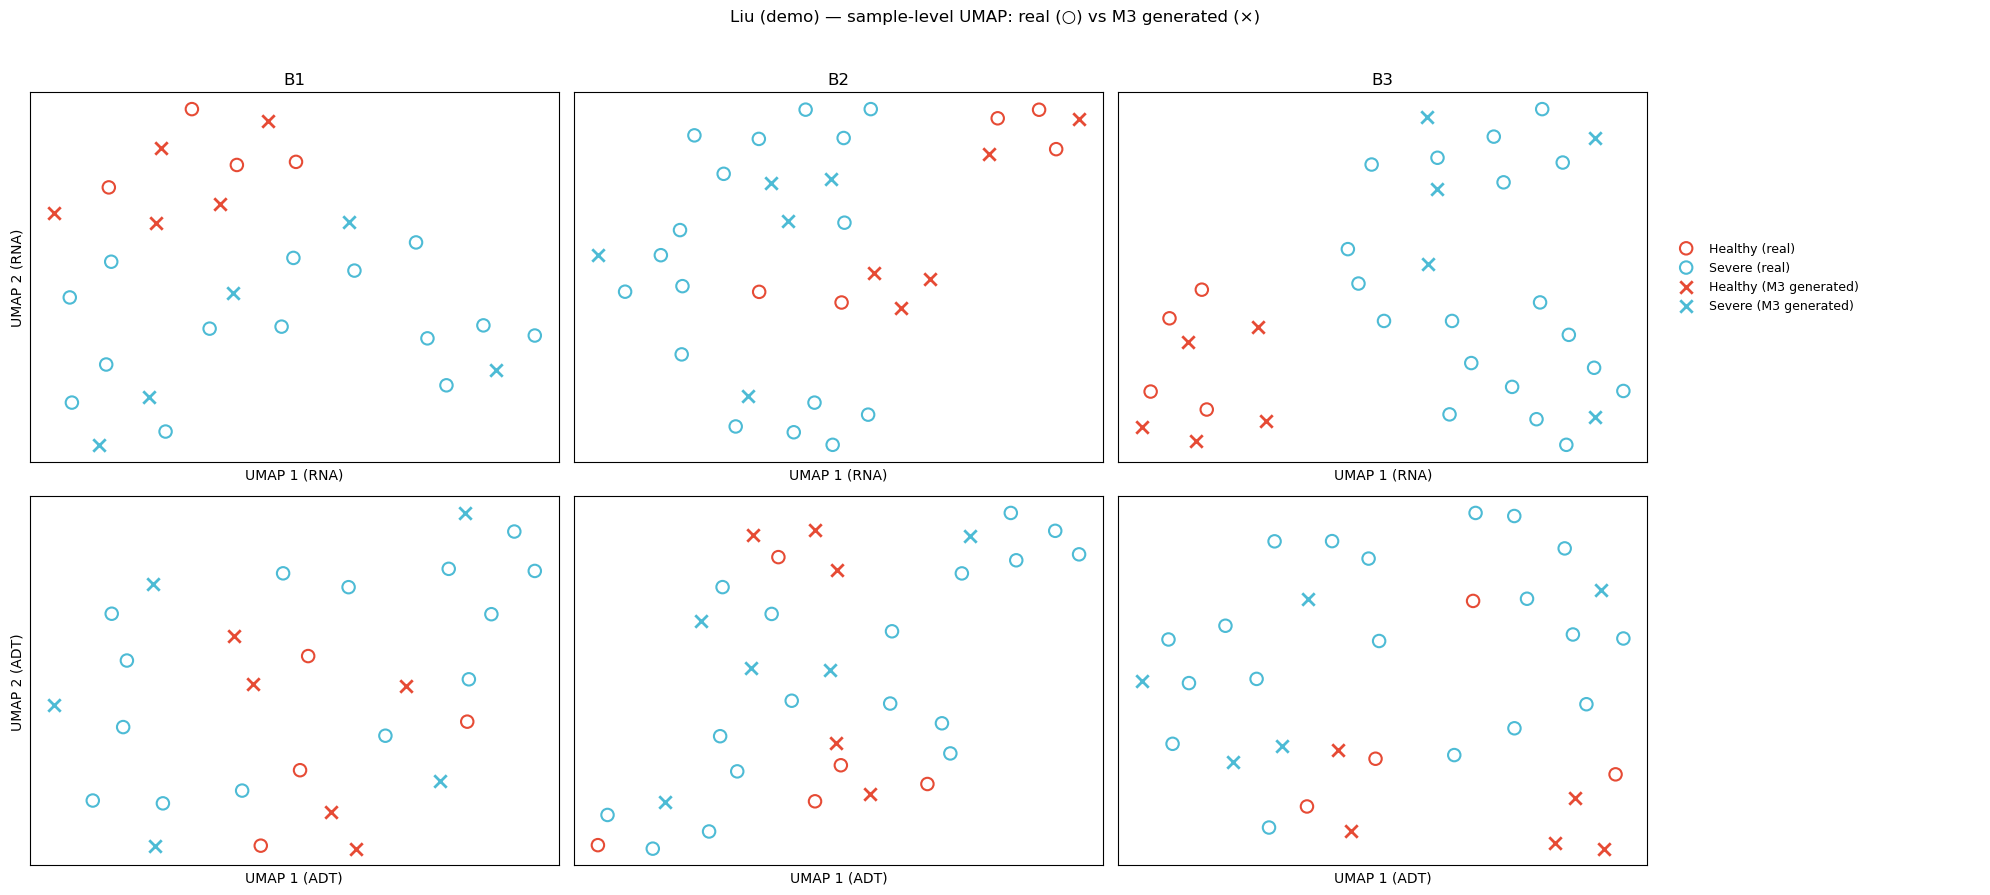

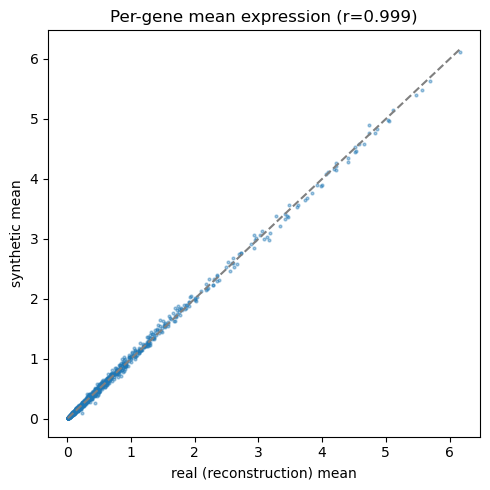

In [5]:
import umap
from sklearn.decomposition import PCA

real_recon = np.nan_to_num(model.reconstruct(remove_batch=False)["rna"])
m_real, m_syn = real_recon.mean(0), np.nan_to_num(syn_rna).mean(0)
pearson = float(np.corrcoef(m_real, m_syn)[0, 1])
print(f"per-gene mean expression Pearson r = {pearson:.3f}")


def _per_sample_mean(X, keys):
    uniq = pd.unique(keys)
    return np.vstack([X[keys == k].mean(0) for k in uniq]), uniq


batches = sorted(data.obs["batch"].astype(str).unique())
N_DONORS = 5

# Plot the real samples in the model's reconstruction (decoder) space — the SAME
# space the generated samples live in — so the comparison is apples-to-apples.
# (Plotting raw counts against decoder output would separate real vs generated by
# space, not condition.) `cell_metadata` is row-aligned with `reconstruct()`.
recon = model.reconstruct(remove_batch=False)
cellmeta = model.cell_metadata
real_meta_all = cellmeta[["sample_id", "cond_group", "batch"]].astype(str).reset_index(drop=True)
real_rna_all = np.nan_to_num(np.asarray(recon["rna"], dtype=np.float32))
real_adt_all = np.nan_to_num(np.asarray(recon["adt"], dtype=np.float32))

fig, axes = plt.subplots(2, len(batches) + 1, figsize=(5 * (len(batches) + 1), 9),
                         squeeze=False, gridspec_kw=dict(width_ratios=[1] * len(batches) + [0.6]))
fig.suptitle("Liu (demo) — sample-level UMAP: real (○) vs M3 generated (×)", y=0.99)

for col, batch in enumerate(batches):
    in_b = (real_meta_all["batch"] == batch).to_numpy()
    real_keys = real_meta_all.loc[in_b, "sample_id"].to_numpy()
    real_rna_smp, sids = _per_sample_mean(real_rna_all[in_b], real_keys)
    real_adt_smp, _ = _per_sample_mean(real_adt_all[in_b], real_keys)
    sample_cond = (real_meta_all.loc[in_b].drop_duplicates("sample_id")
                   .set_index("sample_id")["cond_group"].reindex(sids).to_numpy())

    ag = model.augment(conditions=["HC", "Severe"], n_donors=[N_DONORS, N_DONORS],
                       batch=batch, tau=0.8, seed=42 + col)
    syn_keys = (ag["obs"]["cond_group"].astype(str) + "/" + ag["obs"]["donor"].astype(str)).to_numpy()
    syn_rna_smp, syn_unique = _per_sample_mean(ag["expression"]["rna"], syn_keys)
    syn_adt_smp, _ = _per_sample_mean(ag["expression"]["adt"], syn_keys)
    syn_cond = np.array([k.split("/", 1)[0] for k in syn_unique])

    for row, (modname, real_smp, syn_smp) in enumerate(
            [("RNA", real_rna_smp, syn_rna_smp), ("ADT", real_adt_smp, syn_adt_smp)]):
        ax = axes[row, col]
        X = np.vstack([real_smp, syn_smp]).astype(np.float32)
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        X = X / np.where(norms == 0, 1.0, norms)
        if X.shape[0] > 4:
            xy = umap.UMAP(n_neighbors=min(15, X.shape[0] - 1),
                           min_dist=0.5, spread=1.5, metric="cosine",
                           random_state=0).fit_transform(X)
        else:
            xy = PCA(n_components=2).fit_transform(X)
        xy_real, xy_syn = xy[:len(real_smp)], xy[len(real_smp):]
        for cond_label, color in [("HC", "#E64B35"), ("Severe", "#4DBBD5")]:
            m_real_c = sample_cond == cond_label
            ax.scatter(xy_real[m_real_c, 0], xy_real[m_real_c, 1],
                       facecolors="none", edgecolors=color, s=80, linewidths=1.5)
            m_syn_c = syn_cond == cond_label
            ax.scatter(xy_syn[m_syn_c, 0], xy_syn[m_syn_c, 1],
                       marker="x", c=color, s=80, linewidths=2)
        if row == 0:
            ax.set_title(f"{batch}")
        ax.set_xlabel(f"UMAP 1 ({modname})")
        if col == 0:
            ax.set_ylabel(f"UMAP 2 ({modname})")
        ax.set_xticks([])
        ax.set_yticks([])

for row, ax in enumerate(axes[:, -1]):
    ax.axis("off")
    if row == 0:
        ax.scatter([], [], facecolors="none", edgecolors="#E64B35", s=80, linewidths=1.5,
                   label="Healthy (real)")
        ax.scatter([], [], facecolors="none", edgecolors="#4DBBD5", s=80, linewidths=1.5,
                   label="Severe (real)")
        ax.scatter([], [], marker="x", c="#E64B35", s=80, linewidths=2,
                   label="Healthy (M3 generated)")
        ax.scatter([], [], marker="x", c="#4DBBD5", s=80, linewidths=2,
                   label="Severe (M3 generated)")
        ax.legend(loc="center left", frameon=False, fontsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(os.path.join(OUT, "real_vs_synthetic_samplelevel.png"), dpi=130, bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(5, 5))
ax2.scatter(m_real, m_syn, s=4, alpha=0.4)
lim = [min(m_real.min(), m_syn.min()), max(m_real.max(), m_syn.max())]
ax2.plot(lim, lim, "--", color="grey")
ax2.set(xlabel="real (reconstruction) mean", ylabel="synthetic mean",
        title=f"Per-gene mean expression (r={pearson:.3f})")
fig2.tight_layout()
fig2.savefig(os.path.join(OUT, "real_vs_synthetic_per_gene.png"), dpi=130, bbox_inches="tight")
plt.show()

## Posterior-resampled cells (`generate`)
`generate()` returns one synthetic cell per reference cell (1:1 posterior resample),
handy for noise-augmenting a training set.

In [6]:
gen = model.generate(tau=0.8)
print("generated:", {k: v.shape for k, v in gen.items()})
np.save(os.path.join(OUT, "generated_rna.npy"), gen["rna"])

generated: {'rna': (30534, 1000), 'adt': (30534, 192)}
